# Exploring Data Bias in the Adult Census Income Dataset

### Name: **Tirth Laheri**

### Dataset Used: **UCI Adult (Census Income), 1994 U.S. Census**

### **Project Overview**:

Machine learning models are only as reliable as the data used to train them. If a dataset contains imbalances or historical patterns of discrimination, those biases can be reflected in the model's predictions. Understanding these issues is an important step in developing fair and ethical machine learning systems.

In this project, I analyzed the Adult Census Income Dataset from the UCI Machine Learning Repository to identify different forms of bias that may influence model performance. The analysis focuses on representation bias, educational bias, work-related bias, and geographic representation while using statistical methods and visualizations to support the findings.

# **1. Import Required Libraries**

- The first step is to import all the libraries needed for data analysis, visualization, and statistical testing. Pandas and NumPy are used for data manipulation, while Matplotlib and Seaborn are used to create visualizations. Statistical tests from SciPy help determine whether the observed relationships are statistically significant.

In [3]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported.")

All libraries imported.


# **2. Load the Dataset**

- The Adult Census Income dataset is loaded into a Pandas DataFrame. Before beginning the analysis, it is important to inspect the data to understand its structure, available features, and overall quality.

In [5]:
#load dataset

columns = ["age", "workclass", "fnlwgt", "education", "education_num",
           "marital_status", "occupation", "relationship", "race",
           "sex", "capital_gain", "capital_loss", "hours_per_week",
           "native_country", "income"]

df = pd.read_csv("data/adult.data", names=columns, skipinitialspace=True)

# **3. Dataset Overview**

- Before performing any analysis, it is helpful to examine the size of the dataset, the available variables, and their data types. This provides a general understanding of the information available and helps identify potential issues such as missing values or incorrect data types.

In [6]:
#display first 5 rows

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
#check dataset size

print("Number of rows", df.shape[0])
print("Number of columns", df.shape[1])

Number of rows 32561
Number of columns 15


In [8]:
#check data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# **4. Data Cleaning**

- The dataset contains missing values represented by question marks in several categorical columns. Since these missing records make up only a small portion of the dataset, they are removed to simplify the analysis. Cleaning the dataset ensures that the visualizations and statistical tests are based on complete observations.

In [9]:
#display missing values

missing_values = (df == "?").sum()

print(missing_values)

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [10]:
#replace question marks with missing values
df.replace("?", np.nan, inplace=True)

#remove rows with missing values
df.dropna(inplace=True)

#reset index
df.reset_index(drop=True, inplace=True)

In [11]:
#check missing values after cleaning

print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [12]:
#check dataset size after cleaning

print("Number of rows", df.shape[0])
print("Number of columns", df.shape[1])

Number of rows 30162
Number of columns 15


In [13]:
#look at the first few rows

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [14]:
#display summary statistics

df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


# **5. Income Distribution**

- Understanding the overall distribution of the target variable provides useful context before investigating different sources of bias. The graph below shows that most individuals in the dataset earn $50,000 or less, while a smaller proportion belong to the higher income category. This imbalance should be considered when interpreting later analyses.

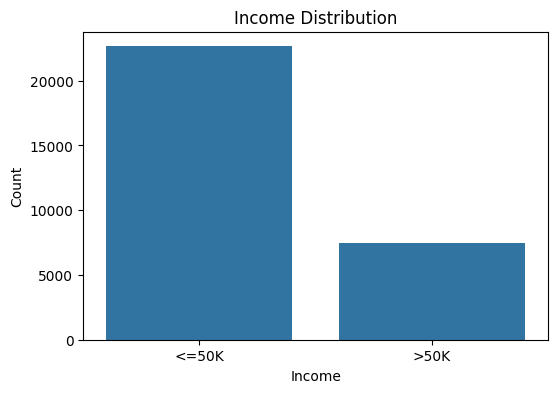

In [15]:
#plot income distribution

plt.figure(figsize=(6,4))

sns.countplot(x="income", data=df)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

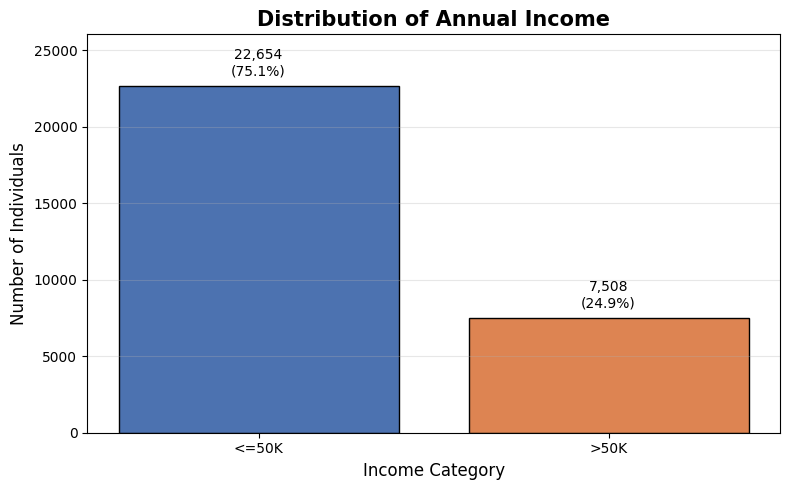

In [17]:
#plot income distribution

income_counts = df["income"].value_counts()

plt.figure(figsize=(8,5))

colors = ["#4C72B0", "#DD8452"]

bars = plt.bar(income_counts.index,
               income_counts.values,
               color=colors,
               edgecolor="black")

plt.title("Distribution of Annual Income", fontsize=15, fontweight="bold")
plt.xlabel("Income Category", fontsize=12)
plt.ylabel("Number of Individuals", fontsize=12)

#add labels on bars
total = income_counts.sum()

for bar in bars:
    height = bar.get_height()
    percent = height / total * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f"{height:,}\n({percent:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

#add extra space at the top

plt.ylim(0, max(income_counts.values) * 1.15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()
plt.show()

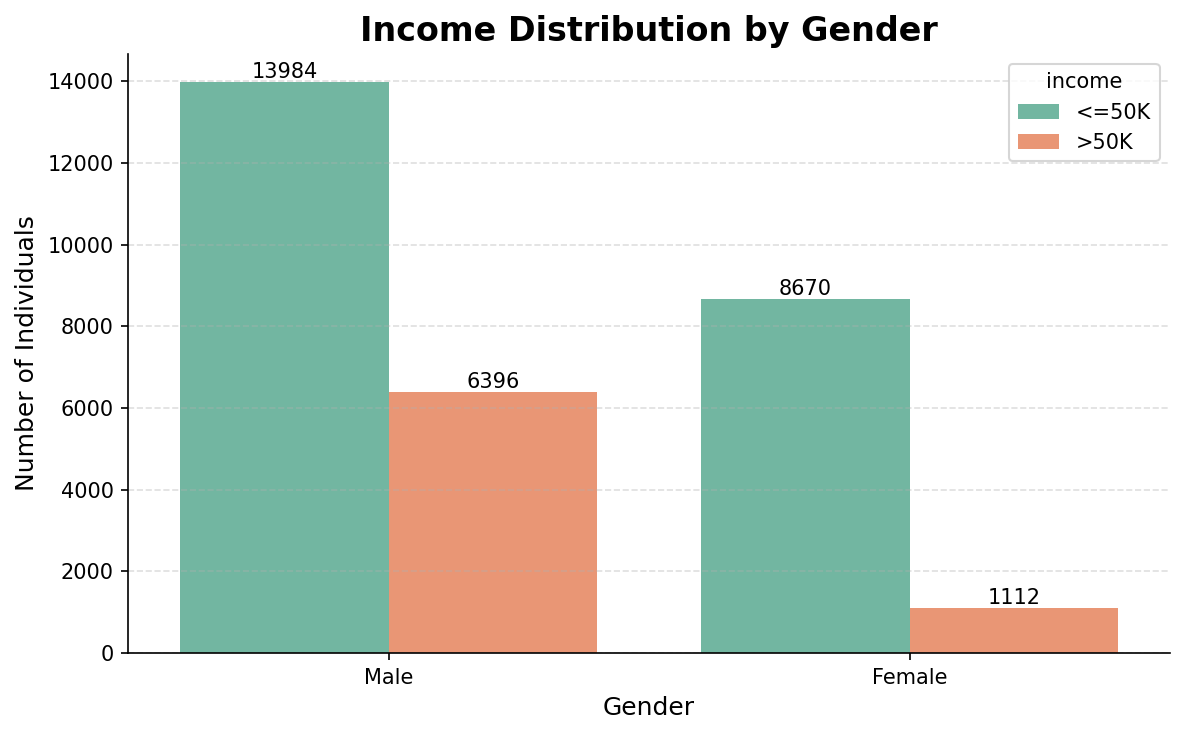

In [18]:
#plot income by gender

plt.figure(figsize=(8,5), dpi=150)

ax = sns.countplot(
    data=df,
    x="sex",
    hue="income",
    palette="Set2"
)

plt.title("Income Distribution by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Individuals", fontsize=12)

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

In [19]:
#calculate income percentage by gender

gender_income = pd.crosstab(df["sex"], df["income"], normalize="index") * 100

gender_income = gender_income.round(2)

gender_income

income,<=50K,>50K
sex,,
Female,88.63,11.37
Male,68.62,31.38


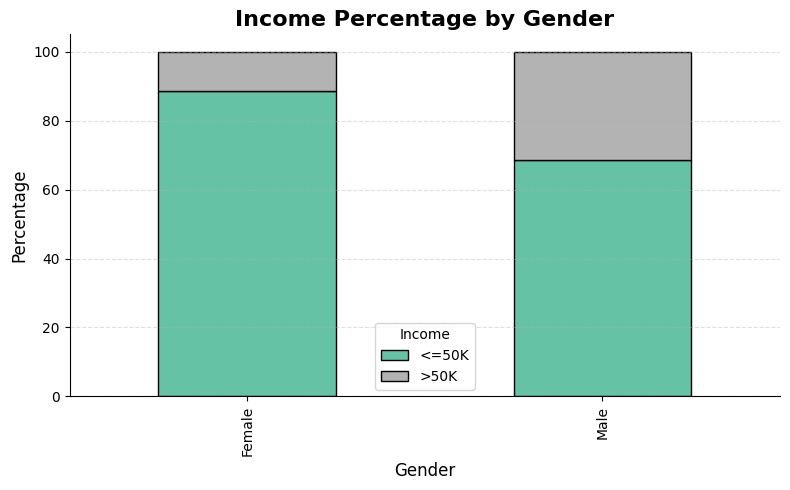

In [20]:
#plot income percentage by gender

gender_income.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Income Percentage by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Percentage", fontsize=12)

plt.legend(title="Income")

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

/tmp/ipykernel_393/156117323.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


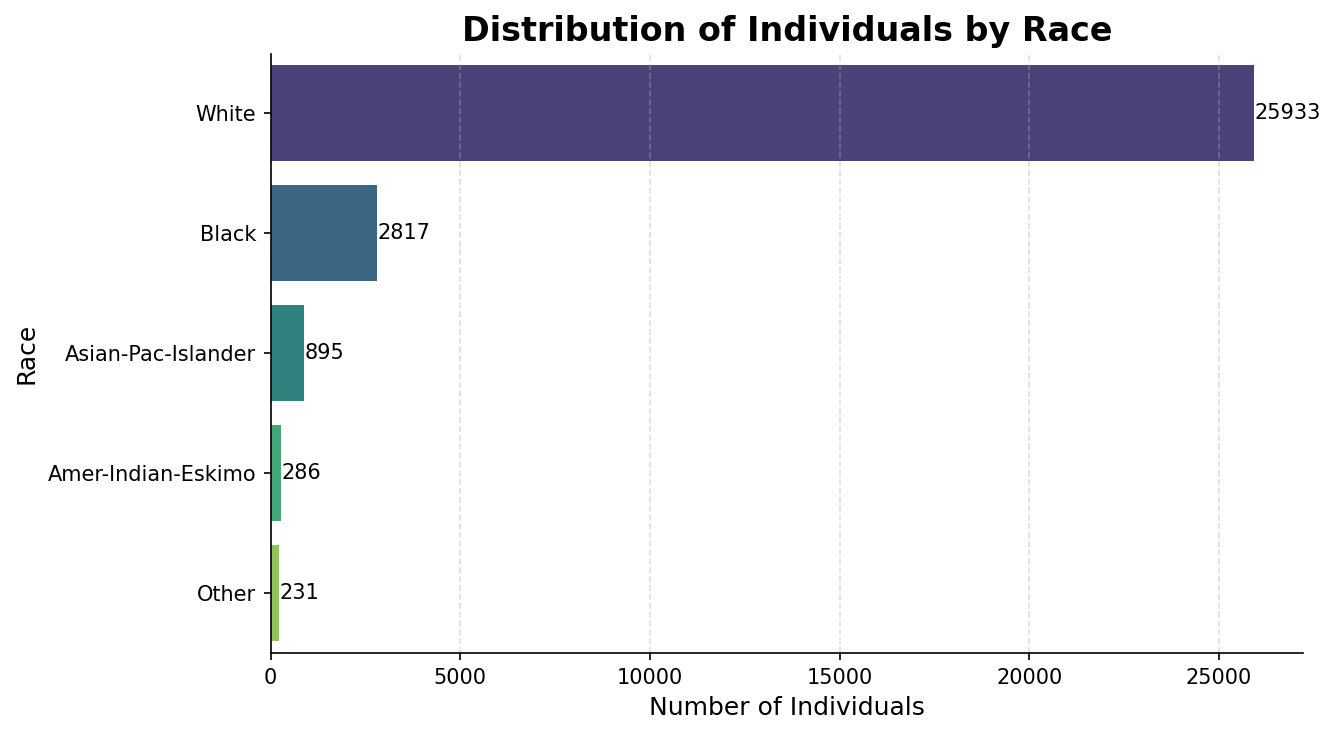

In [21]:
#check race distribution

plt.figure(figsize=(9,5), dpi=150)

ax = sns.countplot(
    data=df,
    y="race",
    order=df["race"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Individuals by Race", fontsize=16, fontweight="bold")
plt.xlabel("Number of Individuals", fontsize=12)
plt.ylabel("Race", fontsize=12)

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="x", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

In [22]:
#calculate income percentage by race

race_income = pd.crosstab(df["race"], df["income"], normalize="index") * 100

race_income = race_income.round(2)

race_income

income,<=50K,>50K
race,,
Amer-Indian-Eskimo,88.11,11.89
Asian-Pac-Islander,72.29,27.71
Black,87.01,12.99
Other,90.91,9.09
White,73.63,26.37


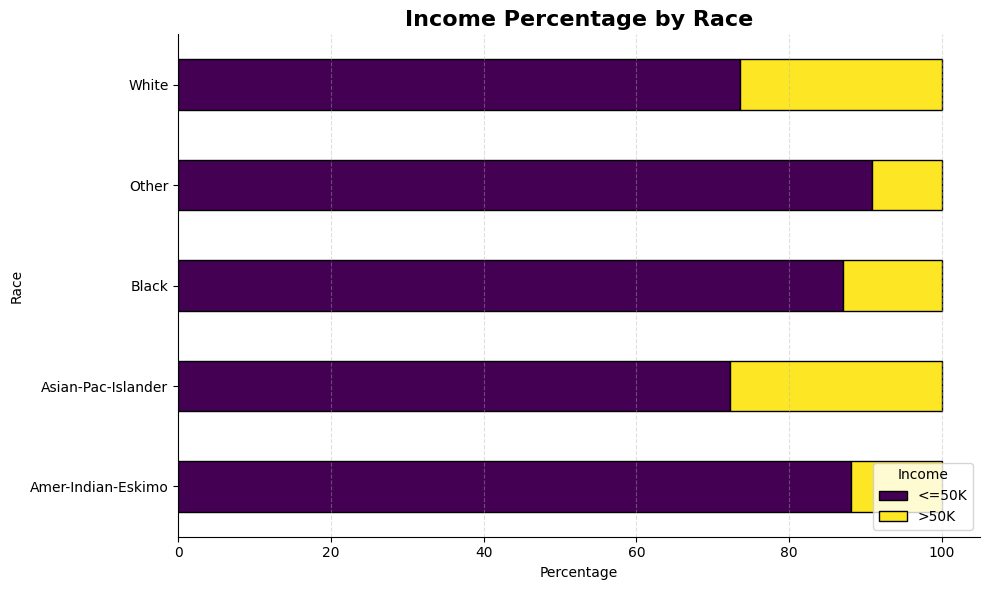

In [23]:
#plot income percentage by race

race_income.plot(
    kind="barh",
    stacked=True,
    figsize=(10,6),
    colormap="viridis",
    edgecolor="black"
)

plt.title("Income Percentage by Race", fontsize=16, fontweight="bold")
plt.xlabel("Percentage")
plt.ylabel("Race")

plt.legend(title="Income", loc="lower right")

plt.grid(axis="x", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

# **6. Education and Income**

- Education is one of the strongest factors associated with income. The following visualizations explore how income changes across different education levels. Looking at percentages instead of raw counts makes it easier to compare education groups of different sizes and better understand the relationship between education and earnings.

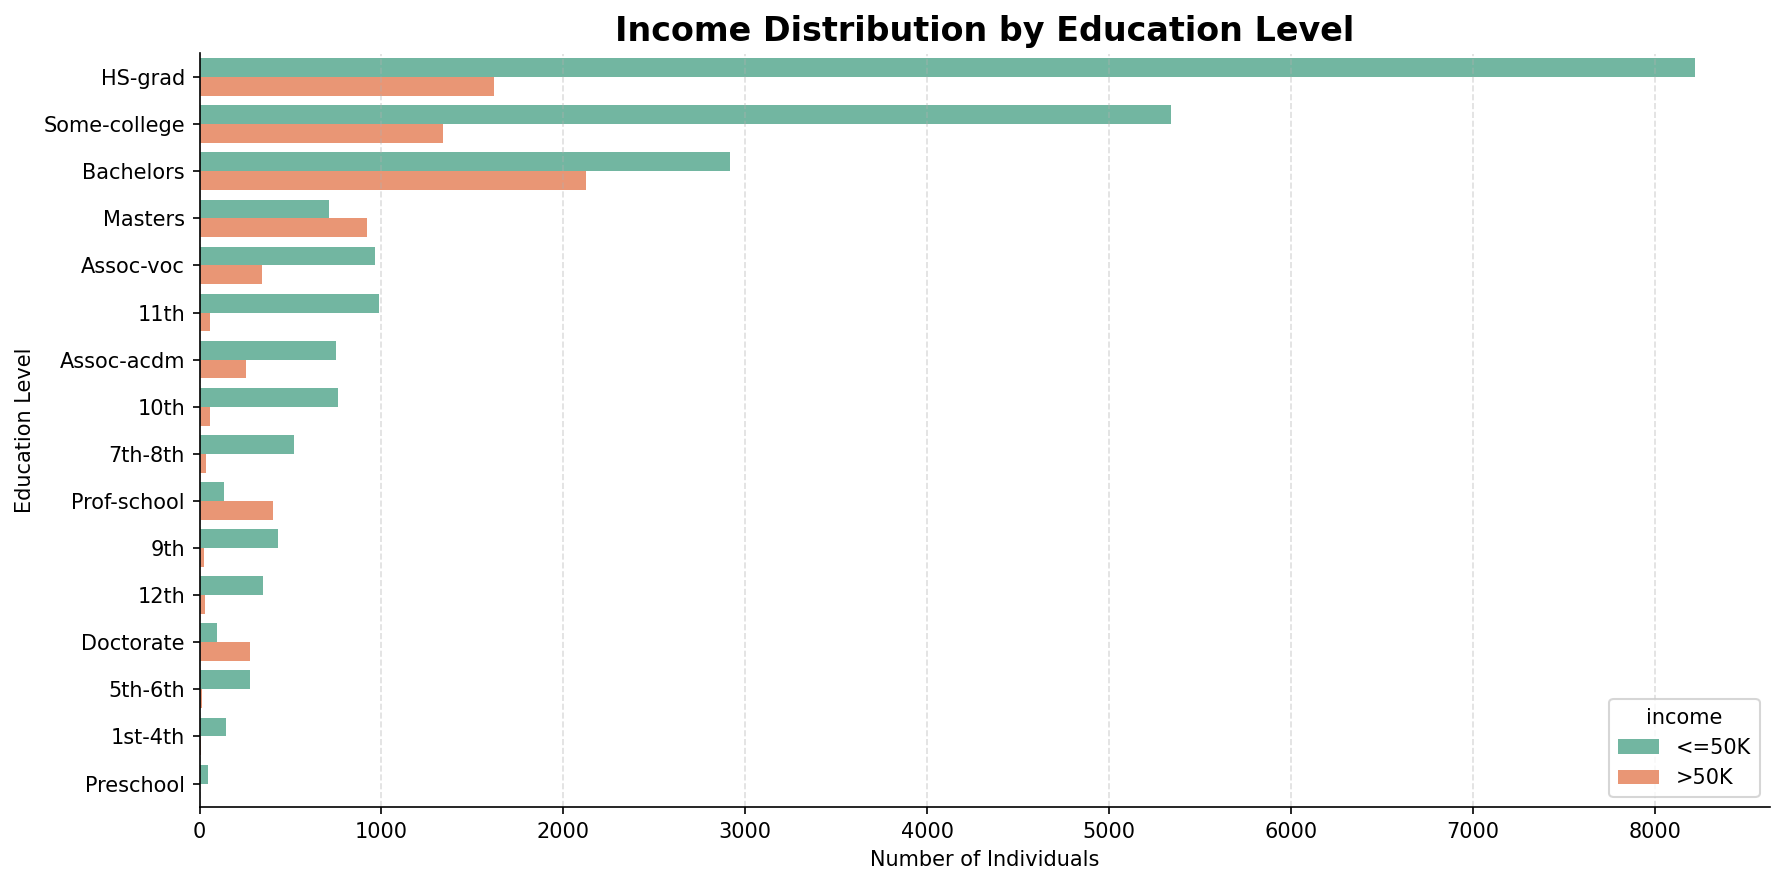

In [24]:
#plot education level by income

plt.figure(figsize=(12,6), dpi=150)

education_order = df["education"].value_counts().index

ax = sns.countplot(
    data=df,
    y="education",
    hue="income",
    order=education_order,
    palette="Set2"
)

plt.title("Income Distribution by Education Level", fontsize=16, fontweight="bold")
plt.xlabel("Number of Individuals")
plt.ylabel("Education Level")

plt.grid(axis="x", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

In [25]:
#calculate income percentage by education

education_income = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
) * 100

education_income = education_income.round(2)

education_income = education_income.sort_values(">50K")

education_income

income,<=50K,>50K
education,,
Preschool,100.00,0.00
1st-4th,96.03,3.97
5th-6th,95.83,4.17
9th,94.51,5.49
11th,94.37,5.63
7th-8th,93.72,6.28
10th,92.80,7.20
12th,92.31,7.69
HS-grad,83.57,16.43


/tmp/ipykernel_393/2984655227.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


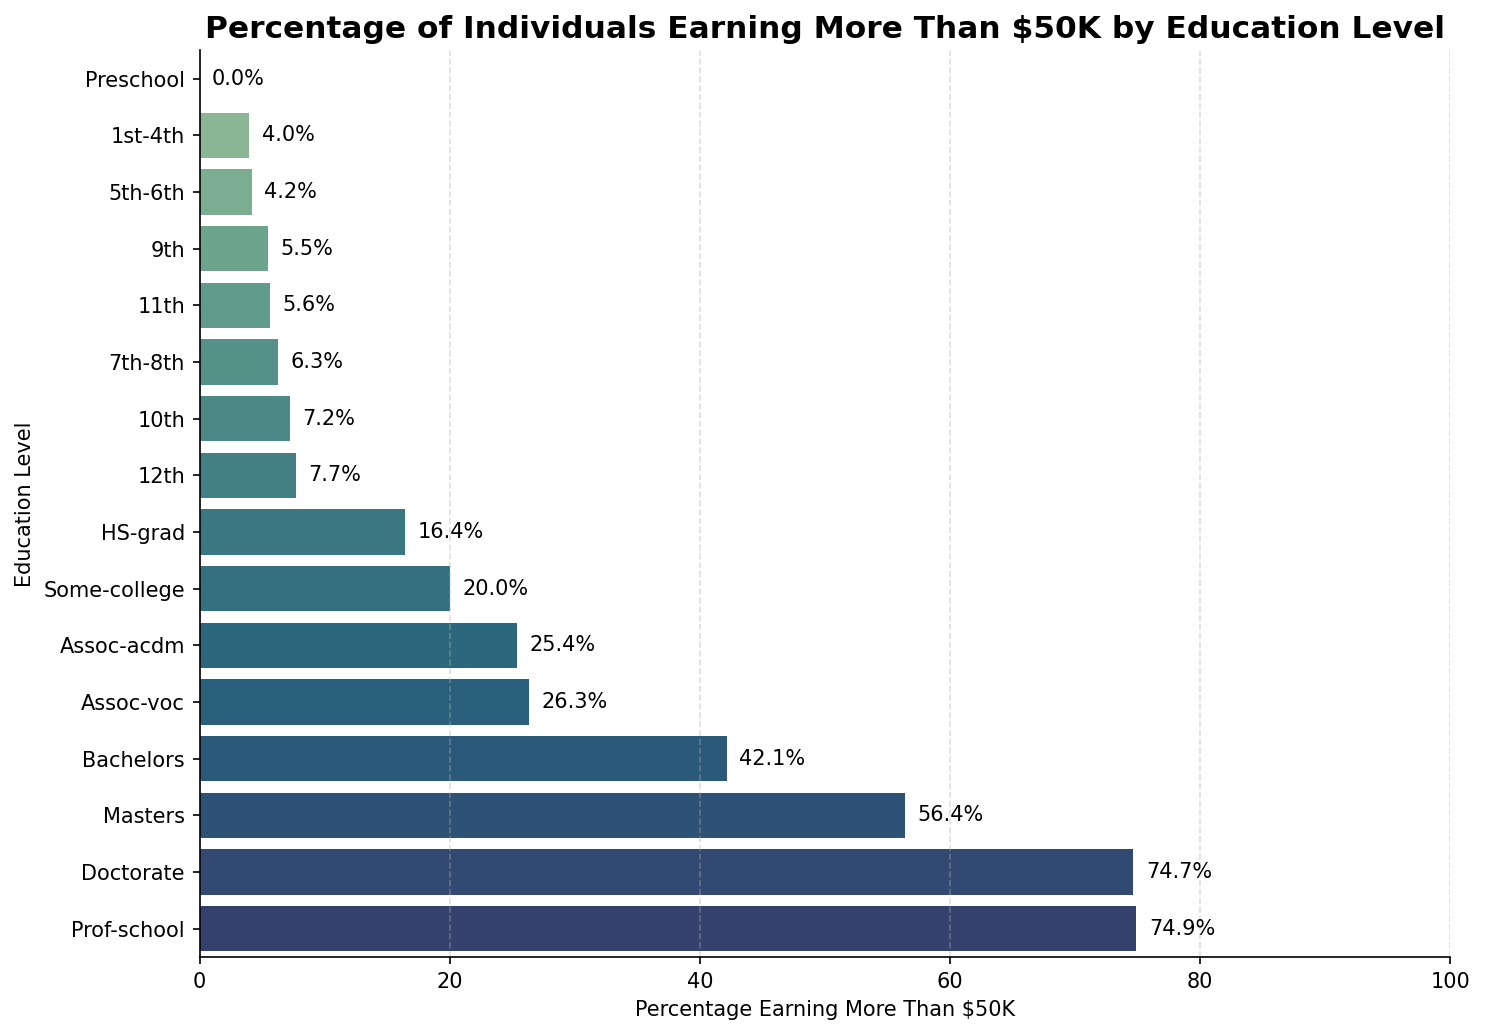

In [26]:
#plot high income percentage by education

high_income = education_income[">50K"].sort_values()

plt.figure(figsize=(10,7), dpi=150)

ax = sns.barplot(
    x=high_income.values,
    y=high_income.index,
    palette="crest"
)

plt.title("Percentage of Individuals Earning More Than $50K by Education Level",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Percentage Earning More Than $50K")
plt.ylabel("Education Level")

for i, value in enumerate(high_income.values):
    plt.text(
        value + 1,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

plt.xlim(0,100)

plt.grid(axis="x", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

### **Observation**

- Individuals with Bachelor's, Master's, Doctorate, and Professional School degrees have a much higher percentage of incomes above $50,000 compared to individuals with lower education levels. This suggests that educational attainment plays an important role in income differences within the dataset.

# **7. Work Hours Analysis**

The number of hours worked each week is another important variable that may influence income. Instead of only comparing average values, a violin plot provides a better understanding of the overall distribution and variation within each income group.

/tmp/ipykernel_393/2902138371.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


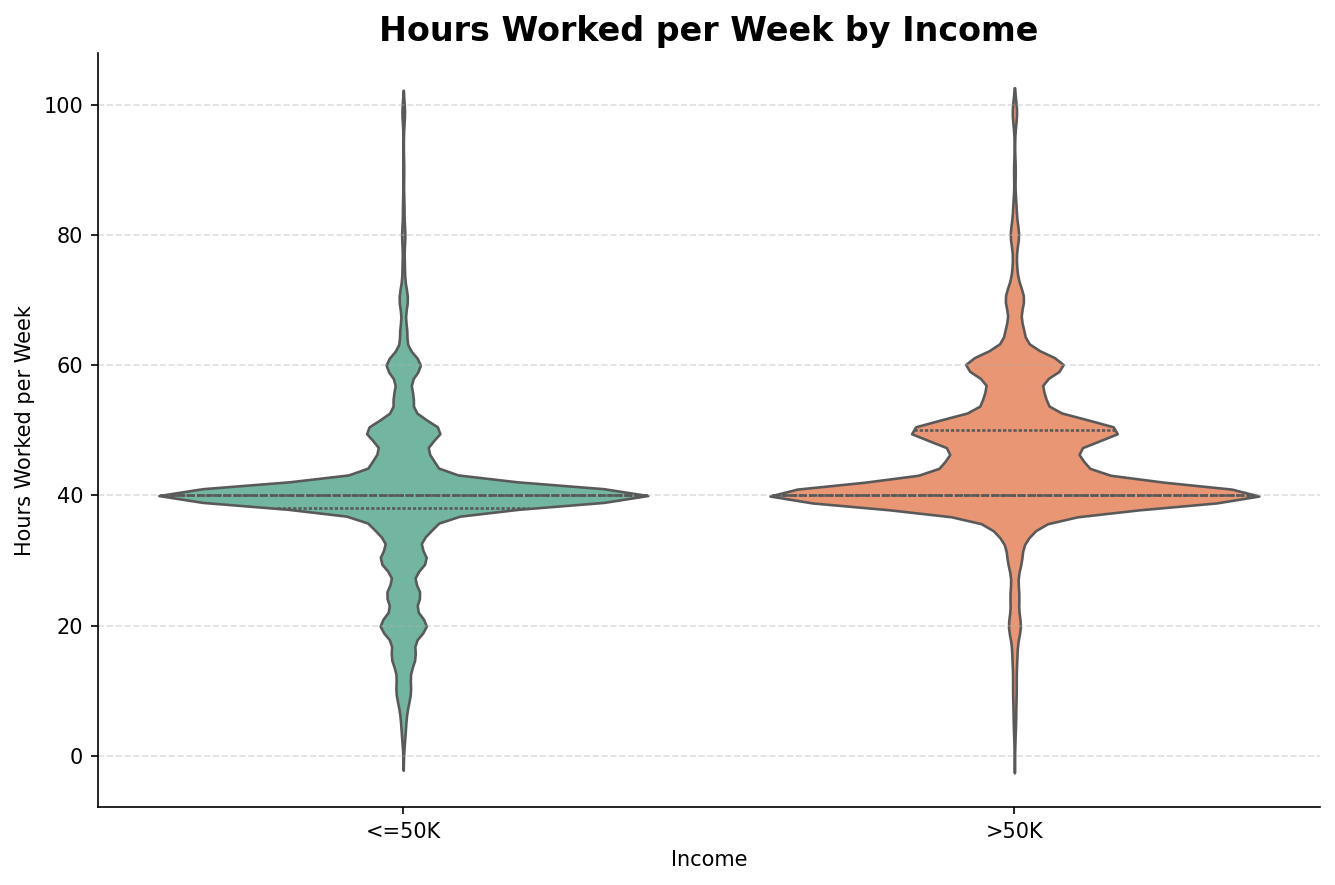

In [27]:
#plot hours worked by income

plt.figure(figsize=(9,6), dpi=150)

sns.violinplot(
    data=df,
    x="income",
    y="hours_per_week",
    palette="Set2",
    inner="quartile"
)

plt.title("Hours Worked per Week by Income", fontsize=16, fontweight="bold")
plt.xlabel("Income")
plt.ylabel("Hours Worked per Week")

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

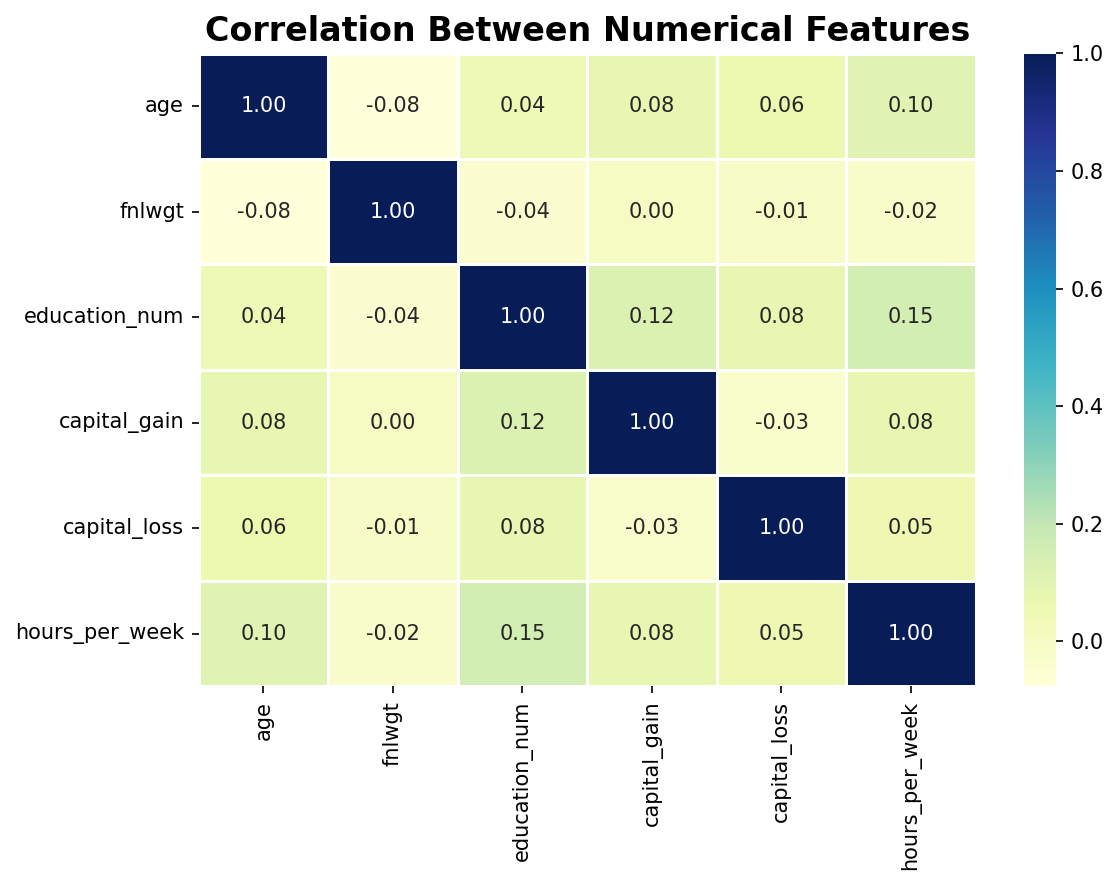

In [28]:
#calculate correlation

correlation = df.select_dtypes(include=["int64"]).corr()

plt.figure(figsize=(8,6), dpi=150)

sns.heatmap(
    correlation,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Features", fontsize=16, fontweight="bold")

plt.tight_layout()

plt.show()

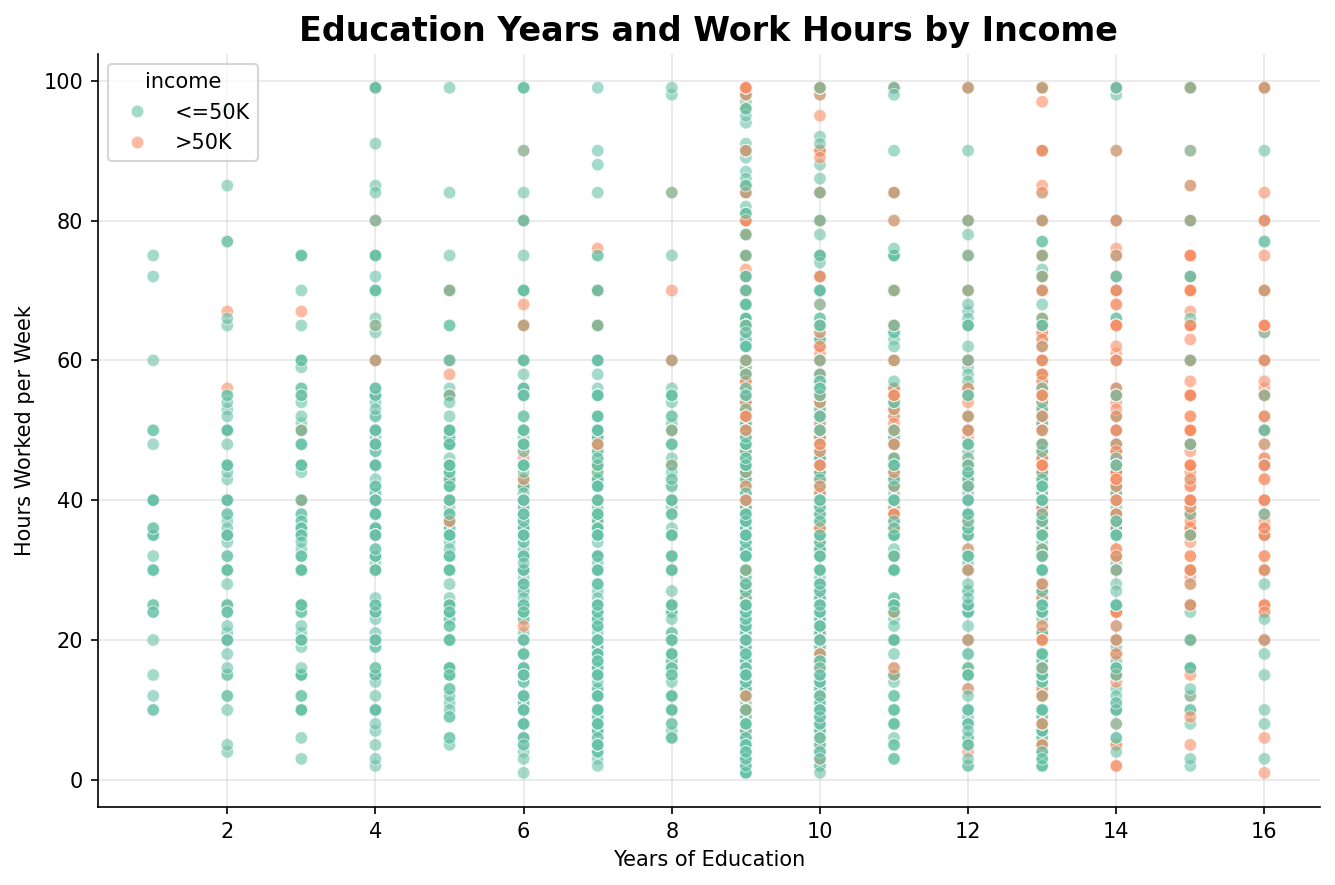

In [29]:
#plot education years and work hours by income

plt.figure(figsize=(9,6), dpi=150)

sns.scatterplot(
    data=df,
    x="education_num",
    y="hours_per_week",
    hue="income",
    alpha=0.6,
    palette="Set2"
)

plt.title("Education Years and Work Hours by Income", fontsize=16, fontweight="bold")
plt.xlabel("Years of Education")
plt.ylabel("Hours Worked per Week")

plt.grid(alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

In [30]:
#chi square test for education and income

from scipy.stats import chi2_contingency

education_table = pd.crosstab(df["education"], df["income"])

chi2, p, dof, expected = chi2_contingency(education_table)

print("Chi Square Statistic")
print(round(chi2,2))

print()

print("P Value")
print(p)

print()

print("Degrees of Freedom")
print(dof)

if p < 0.05:
    print("\nThere is a statistically significant relationship between education level and income.")
else:
    print("\nThere is no statistically significant relationship between education level and income.")

Chi Square Statistic
4070.38

P Value
0.0

Degrees of Freedom
15

There is a statistically significant relationship between education level and income.


### **Observation**

- Individuals earning more than $50,000 generally tend to work longer hours per week. However, there is still considerable variation within both income groups, indicating that work hours alone do not fully explain income differences.

# **8. Native Country Representation**

- Representation bias occurs when certain groups appear much more frequently than others within a dataset. The following visualization examines how individuals from different countries are represented in the Adult Census Income dataset.

/tmp/ipykernel_393/3926748561.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


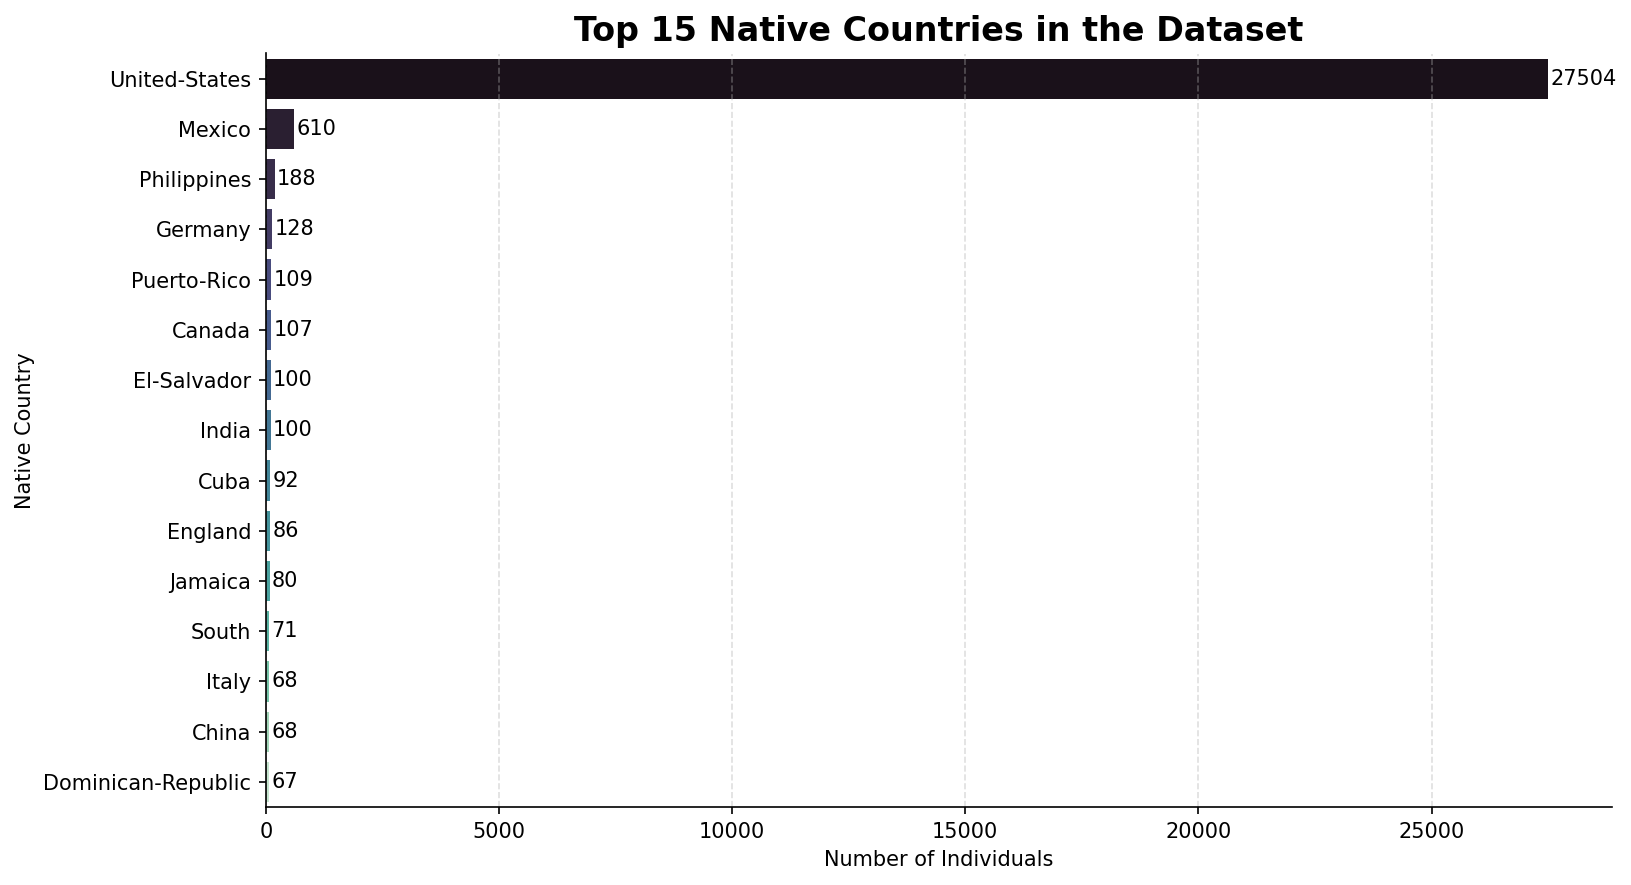

In [31]:
#plot top 15 native countries

top_countries = df["native_country"].value_counts().head(15)

plt.figure(figsize=(11,6), dpi=150)

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="mako"
)

plt.title("Top 15 Native Countries in the Dataset", fontsize=16, fontweight="bold")
plt.xlabel("Number of Individuals")
plt.ylabel("Native Country")

for i, value in enumerate(top_countries.values):
    plt.text(value + 50, i, str(value), va="center")

plt.grid(axis="x", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

### **Observation**

- Most records belong to individuals from the United States, while many other countries are represented by only a small number of observations. This imbalance may reduce the ability of machine learning models to generalize fairly across different populations.

# **9. Workclass Analysis**

- Different employment categories may also influence income. A heatmap allows the relationship between workclass and income to be viewed more clearly than a simple frequency table.

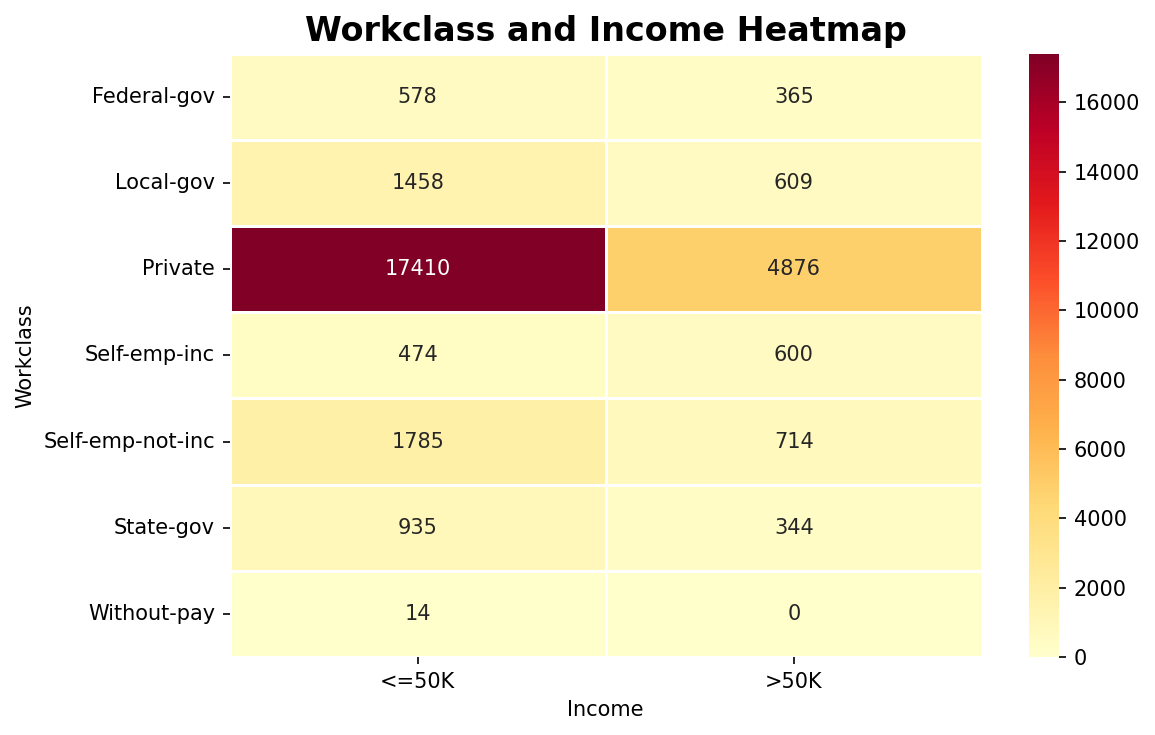

In [32]:
#plot workclass and income heatmap

workclass_income = pd.crosstab(
    df["workclass"],
    df["income"]
)

plt.figure(figsize=(8,5), dpi=150)

sns.heatmap(
    workclass_income,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Workclass and Income Heatmap", fontsize=16, fontweight="bold")
plt.xlabel("Income")
plt.ylabel("Workclass")

plt.tight_layout()

plt.show()

### **Observation**

- The majority of individuals in the dataset work in the private sector. Higher income observations are also concentrated within this workclass, while several other employment categories contain comparatively fewer records.

# **10. Results Summary**

The analysis revealed several meaningful patterns within the Adult Census Income dataset. After cleaning the data, **30,162 complete records** remained for analysis. The visualizations and statistical tests consistently showed that several demographic and socioeconomic factors are associated with income.

Some of the key findings are summarized below.

* Approximately **75.1%** of individuals earn **USD 50,000 or less**, while **24.9%** earn **more than USD 50,000**.
* Education showed one of the strongest relationships with income. Nearly **74.9%** of individuals with a **Professional School** degree and **74.7%** of individuals with a **Doctorate** earned **more than USD 50,000**, compared to only **16.4%** of individuals whose highest education level was **High School**.
* The dataset shows a strong **representation imbalance**. More than **27,500** observations come from individuals in the **United States**, while many other countries contribute **fewer than 100 records** each. This imbalance may reduce the ability of machine learning models to generalize across different populations.
* Individuals earning **more than USD 50,000** generally worked **more hours per week** than those earning **USD 50,000 or less**, although some variation was observed within both income groups.
* The **Private** workclass contains the largest number of observations in the dataset. This indicates that employment records are concentrated within one workclass, which may also influence model behavior if left unaddressed.

# **11. Ethical Implications**

Several forms of bias were identified throughout this analysis.

- The dataset contains a clear representation imbalance, particularly in terms of native country. Since the majority of observations come from individuals living in the United States, machine learning models trained on this dataset may not generalize well to other populations.

- Educational differences also create an important source of bias. Individuals with higher education levels are much more likely to belong to the higher income category. While this reflects real socioeconomic patterns, models trained on this data may unintentionally reinforce these disparities if education is heavily weighted during prediction.

- Similarly, differences in workclass and weekly working hours demonstrate that socioeconomic characteristics influence income outcomes. These variables should be carefully evaluated when developing predictive models to avoid reinforcing existing inequalities.

Understanding these biases is an important step toward developing fair, transparent, and responsible machine learning systems.

# **12. Limitations**

Although the Adult Census Income dataset is widely used for research, it has several limitations.

* The data represents census information collected in the 1990s and may not accurately reflect current workforce demographics.
* Several countries have very small sample sizes, limiting meaningful comparisons across populations.
* Missing records were removed during preprocessing, which slightly reduced the dataset size.
* The analysis focused primarily on identifying patterns rather than establishing causal relationships.

These limitations should be considered when interpreting the results and applying the findings to modern machine learning applications.

# **13. Conclusion**

This project explored multiple sources of bias within the Adult Census Income dataset using exploratory data analysis, visualization, and statistical testing.

The findings demonstrate that education level, workclass, weekly work hours, and representation across native countries all contribute to noticeable differences in income. Statistical testing confirmed that the relationship between education and income is highly significant, supporting the trends observed throughout the analysis.

Overall, this project highlights the importance of examining datasets before building predictive models. Identifying potential sources of bias early allows data scientists to make more informed decisions, improve model fairness, and reduce the risk of unintended discrimination in real world applications.